# SPP Decomposition: Analyzing Large Amplitude Oscillatory Shear (LAOS)

This notebook demonstrates the **SPP (Sequence of Physical Processes)** Decomposer transform
for LAOS analysis in RheoJAX.

## Overview

- **LAOS experiments** probe nonlinear viscoelasticity by applying oscillatory strain at amplitudes
  beyond the linear regime, revealing yield, flow, and stiffening behaviors
- **SPP framework** (Rogers et al., J. Rheol. 2012, 2017) decomposes the measured stress into
  physically meaningful elastic and viscous contributions on a cycle-by-cycle basis
- **RheoJAX `SPPDecomposer`** extracts yield stresses, power-law flow parameters, Lissajous
  metrics, and harmonic content from time-domain LAOS data

## Learning Objectives

1. Generate synthetic LAOS data with controlled harmonic content
2. Apply `SPPDecomposer` and interpret the results dictionary
3. Visualize elastic and viscous Lissajous-Bowditch curves
4. Inspect the elastic/viscous stress decomposition in the time domain
5. Use `spp_analyze()` for quick single-shot analysis
6. Study nonlinearity metrics as a function of strain amplitude

**Estimated time:** ~35-45 min

In [1]:
# Colab setup — install RheoJAX when running outside a local environment
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "rheojax", "--quiet"],
        check=True,
    )
    print("RheoJAX installed.")

## Setup and Imports

In [2]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from rheojax.core.data import RheoData
from rheojax.core.jax_config import safe_import_jax, verify_float64
from rheojax.transforms.spp_decomposer import SPPDecomposer, spp_analyze

jax, jnp = safe_import_jax()
verify_float64()
print("JAX float64 precision enabled")

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
warnings.filterwarnings("ignore", message=".*non-interactive.*")

JAX float64 precision enabled


## Theory: LAOS and the SPP Framework

### Oscillatory Strain Protocol

In a LAOS experiment the applied strain is:

$$\gamma(t) = \gamma_0 \sin(\omega t)$$

At large amplitudes ($\gamma_0 \gg \gamma_{\text{lin}}$) the material enters the nonlinear regime.

### Nonlinear Stress Response

The measured stress contains odd harmonics (by symmetry for isotropic materials):

$$\sigma(t) = \sum_{n=1,3,5,\ldots} \sigma_n \sin(n\omega t + \varphi_n)$$

Fourier Transform Rheology (FT-Rheology) quantifies nonlinearity via the relative third-harmonic
intensity $I_3/I_1 = \sigma_3 / \sigma_1$.

### SPP Decomposition (Rogers et al.)

The SPP framework goes beyond harmonic amplitudes by defining time-resolved moduli $G'(t)$,
$G''(t)$ and decomposing stress into physical contributions:

$$\sigma(t) = \sigma_{\text{elastic}}(t) + \sigma_{\text{viscous}}(t)$$

### Key Output Quantities

| Quantity | Symbol | Physical meaning |
|---|---|---|
| Static yield stress | $\sigma_{sy}$ | Stress at strain reversal ($|\gamma| = \gamma_0$) |
| Dynamic yield stress | $\sigma_{dy}$ | Stress at rate reversal ($|\dot{\gamma}| = 0$) |
| Large-strain modulus | $G_L$ | Tangent modulus at $\gamma = \pm\gamma_0$ |
| Minimum-strain modulus | $G_M$ | Tangent modulus at $\gamma = 0$ |
| S-factor | $S = (G_L - G_M)/G_L$ | Strain stiffening ($S > 0$) or softening ($S < 0$) |
| T-factor | $T = (\eta_L - \eta_M)/\eta_L$ | Shear thickening ($T > 0$) or thinning ($T < 0$) |
| Cage modulus | $G_{\text{cage}}$ | Apparent elastic modulus from stress/strain ratio |
| Third-harmonic ratio | $I_3/I_1$ | FT-rheology nonlinearity index |

## Generate Synthetic LAOS Data

LAOS Parameters:
  omega    = 1.0 rad/s
  gamma_0  = 1.0
  Points   = 2048, Cycles = 2
  I3/I1 (input) = 0.150


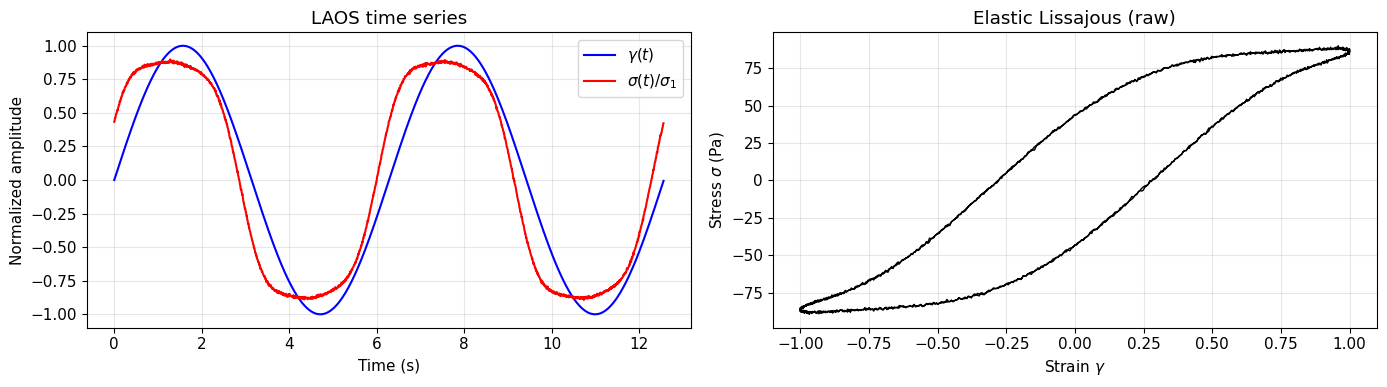

In [3]:
omega = 1.0       # rad/s
gamma_0 = 1.0     # strain amplitude
n_points = 2048   # points per period for 2 full cycles
n_cycles = 2

T_period = 2 * np.pi / omega
t = np.linspace(0, n_cycles * T_period, n_points, endpoint=False)

strain = gamma_0 * np.sin(omega * t)
strain_rate = gamma_0 * omega * np.cos(omega * t)

# Nonlinear stress: fundamental + 3rd + 5th harmonics
sigma_1 = 100.0   # fundamental amplitude (Pa)
sigma_3 = 15.0    # 3rd harmonic — moderate nonlinearity
sigma_5 = 3.0     # 5th harmonic

stress = (
    sigma_1 * np.sin(omega * t + 0.3)
    + sigma_3 * np.sin(3 * omega * t + 0.8)
    + sigma_5 * np.sin(5 * omega * t + 1.2)
)

# Small measurement noise
stress += 0.5 * np.random.randn(len(t))

print("LAOS Parameters:")
print(f"  omega    = {omega} rad/s")
print(f"  gamma_0  = {gamma_0}")
print(f"  Points   = {n_points}, Cycles = {n_cycles}")
print(f"  I3/I1 (input) = {sigma_3 / sigma_1:.3f}")

# Quick preview
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t, strain, "b-", linewidth=1.5, label=r"$\gamma(t)$")
axes[0].plot(t, stress / sigma_1, "r-", linewidth=1.5, label=r"$\sigma(t)/\sigma_1$")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Normalized amplitude")
axes[0].set_title("LAOS time series")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(strain, stress, "k-", linewidth=1.0)
axes[1].set_xlabel(r"Strain $\gamma$")
axes[1].set_ylabel(r"Stress $\sigma$ (Pa)")
axes[1].set_title("Elastic Lissajous (raw)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Apply SPP Decomposition

In [4]:
# Build RheoData — strain is passed via metadata so SPPDecomposer can use it directly
data = RheoData(
    x=t,
    y=stress,
    domain="time",
    metadata={
        "test_mode": "oscillation",
        "omega": omega,
        "gamma_0": gamma_0,
        "strain": strain,
    },
)

# Instantiate and run
decomposer = SPPDecomposer(omega=omega, gamma_0=gamma_0, n_harmonics=7)
result = decomposer.transform(data)
results = decomposer.get_results()

print("SPP Results:")
print(f"  Static yield stress  sigma_sy = {results['sigma_sy']:.2f} Pa")
print(f"  Dynamic yield stress sigma_dy = {results['sigma_dy']:.2f} Pa")
print(f"  Power-law K = {results['K']:.3f} Pa*s^n,  n = {results['n_power_law']:.3f}")
print(f"  I3/I1       = {results['I3_I1_ratio']:.4f}")
print(f"  S-factor    = {results['S_factor']:.4f}")
print(f"  T-factor    = {results['T_factor']:.4f}")
print(f"  G_L = {results['G_L']:.2f} Pa,  G_M = {results['G_M']:.2f} Pa")
print(f"  eta_L = {results['eta_L']:.2f} Pa*s,  eta_M = {results['eta_M']:.2f} Pa*s")

SPP Results:
  Static yield stress  sigma_sy = 86.00 Pa
  Dynamic yield stress sigma_dy = 86.18 Pa
  Power-law K = 49.535 Pa*s^n,  n = -0.491
  I3/I1       = 0.1500
  S-factor    = -0.5859
  T-factor    = 0.6364
  G_L = 86.00 Pa,  G_M = 136.38 Pa
  eta_L = 41.90 Pa*s,  eta_M = 15.24 Pa*s


## Visualize Lissajous-Bowditch Curves

Lissajous-Bowditch (LB) plots are the standard visualization for LAOS data:

- **Elastic LB** ($\sigma$ vs $\gamma$): slope at $\gamma=0$ gives $G_M$; slope at
  $\gamma=\pm\gamma_0$ gives $G_L$
- **Viscous LB** ($\sigma$ vs $\dot{\gamma}$): slope at $\dot{\gamma}=0$ gives $\eta_M$;
  slope at $\dot{\gamma}=\pm\dot{\gamma}_0$ gives $\eta_L$

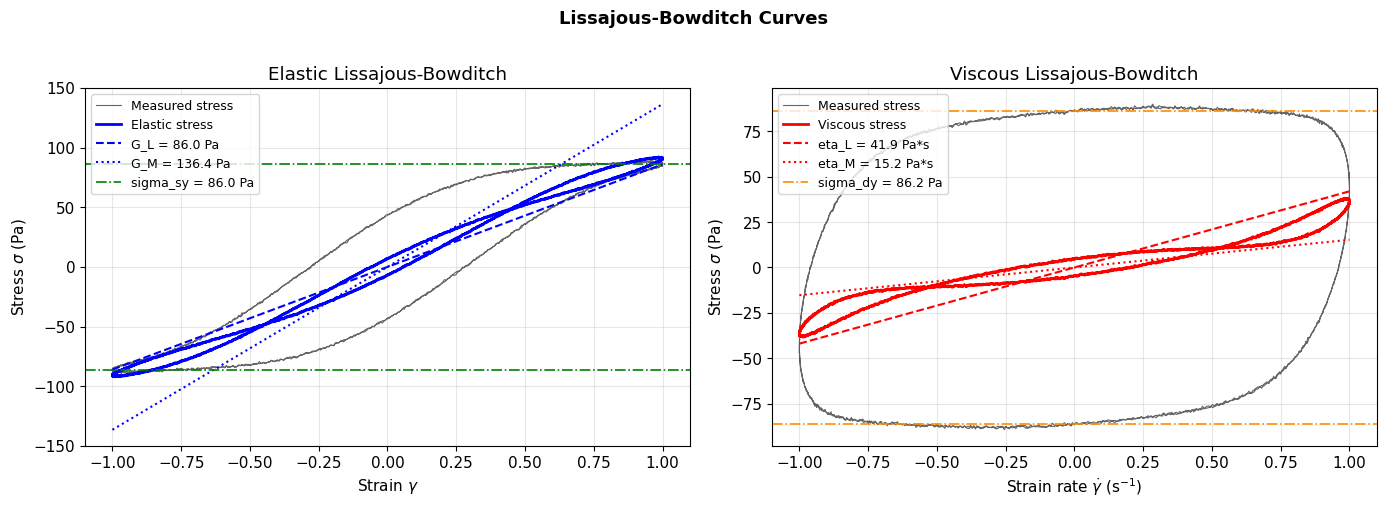

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Elastic Lissajous: sigma vs gamma ---
ax = axes[0]
ax.plot(strain, stress, "k-", linewidth=0.8, alpha=0.6, label="Measured stress")
ax.plot(strain, results["sigma_elastic"], "b-", linewidth=2, label="Elastic stress")

# Draw G_L and G_M tangent lines through origin
gamma_range = np.linspace(-gamma_0, gamma_0, 100)
ax.plot(
    gamma_range,
    results["G_L"] * gamma_range,
    "b--",
    linewidth=1.5,
    label=f"G_L = {results['G_L']:.1f} Pa",
)
ax.plot(
    gamma_range,
    results["G_M"] * gamma_range,
    "b:",
    linewidth=1.5,
    label=f"G_M = {results['G_M']:.1f} Pa",
)
ax.axhline(results["sigma_sy"], color="green", linestyle="-.", linewidth=1.2,
           label=f"sigma_sy = {results['sigma_sy']:.1f} Pa")
ax.axhline(-results["sigma_sy"], color="green", linestyle="-.", linewidth=1.2)
ax.set_xlabel(r"Strain $\gamma$")
ax.set_ylabel(r"Stress $\sigma$ (Pa)")
ax.set_title("Elastic Lissajous-Bowditch")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Viscous Lissajous: sigma vs gamma_dot ---
ax = axes[1]
ax.plot(strain_rate, stress, "k-", linewidth=0.8, alpha=0.6, label="Measured stress")
ax.plot(strain_rate, results["sigma_viscous"], "r-", linewidth=2, label="Viscous stress")

gamma_dot_0 = omega * gamma_0
gdot_range = np.linspace(-gamma_dot_0, gamma_dot_0, 100)
ax.plot(
    gdot_range,
    results["eta_L"] * gdot_range,
    "r--",
    linewidth=1.5,
    label=f"eta_L = {results['eta_L']:.1f} Pa*s",
)
ax.plot(
    gdot_range,
    results["eta_M"] * gdot_range,
    "r:",
    linewidth=1.5,
    label=f"eta_M = {results['eta_M']:.1f} Pa*s",
)
ax.axhline(results["sigma_dy"], color="darkorange", linestyle="-.", linewidth=1.2,
           label=f"sigma_dy = {results['sigma_dy']:.1f} Pa")
ax.axhline(-results["sigma_dy"], color="darkorange", linestyle="-.", linewidth=1.2)
ax.set_xlabel(r"Strain rate $\dot{\gamma}$ (s$^{-1}$)")
ax.set_ylabel(r"Stress $\sigma$ (Pa)")
ax.set_title("Viscous Lissajous-Bowditch")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle("Lissajous-Bowditch Curves", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Stress Decomposition

The SPP transform decomposes the total stress into:

- **Elastic stress** $\sigma_{\text{elastic}}(t)$: in-phase with strain — energy stored
- **Viscous stress** $\sigma_{\text{viscous}}(t)$: in-phase with strain rate — energy dissipated

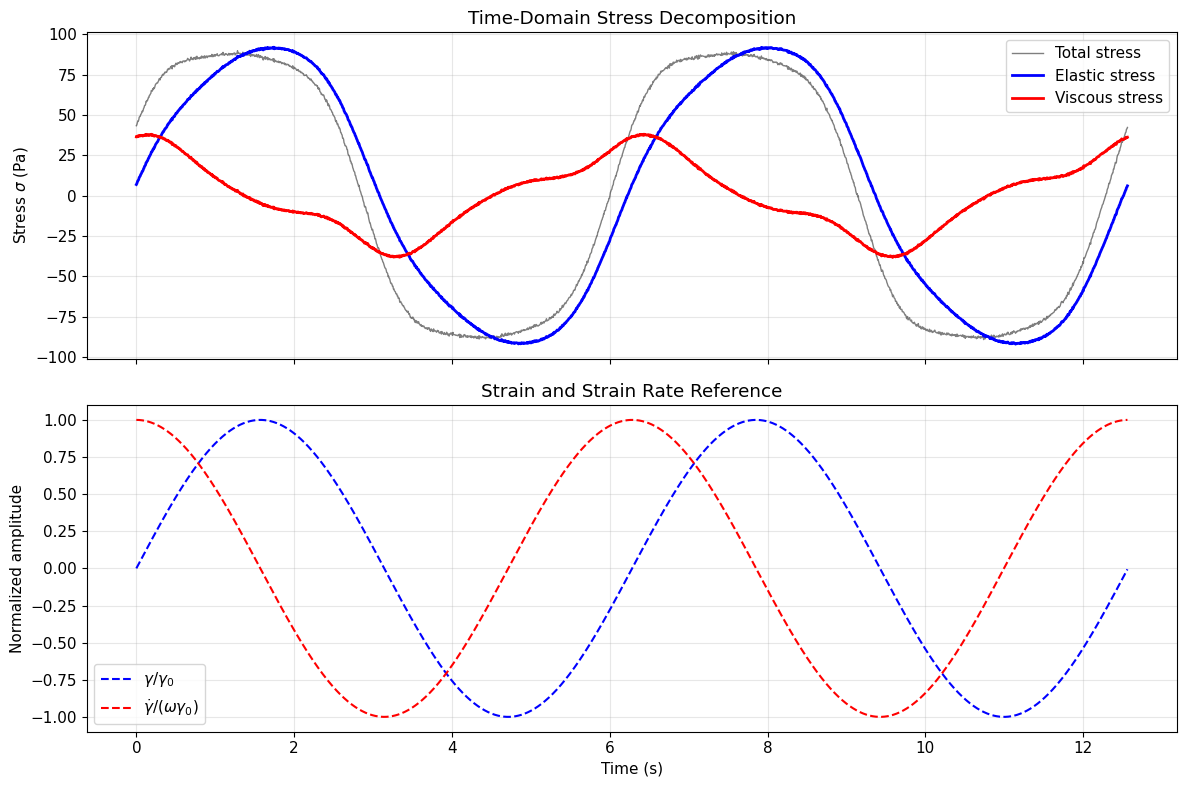

RMS stress fractions:
  Elastic  : 94.7%
  Viscous  : 30.2%


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: total and decomposed stresses
ax = axes[0]
ax.plot(t, stress, "k-", linewidth=1.0, alpha=0.5, label="Total stress")
ax.plot(t, results["sigma_elastic"], "b-", linewidth=2, label="Elastic stress")
ax.plot(t, results["sigma_viscous"], "r-", linewidth=2, label="Viscous stress")
ax.set_ylabel(r"Stress $\sigma$ (Pa)")
ax.set_title("Time-Domain Stress Decomposition")
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom: strain and strain rate (normalized) for phase reference
ax = axes[1]
ax.plot(t, strain / gamma_0, "b--", linewidth=1.5, label=r"$\gamma / \gamma_0$")
ax.plot(
    t,
    strain_rate / (omega * gamma_0),
    "r--",
    linewidth=1.5,
    label=r"$\dot{\gamma} / (\omega\gamma_0)$",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized amplitude")
ax.set_title("Strain and Strain Rate Reference")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Fraction of stress carried by each component (RMS)
rms_total = np.sqrt(np.mean(stress**2))
rms_el = np.sqrt(np.mean(results["sigma_elastic"]**2))
rms_vi = np.sqrt(np.mean(results["sigma_viscous"]**2))
print(f"RMS stress fractions:")
print(f"  Elastic  : {100 * rms_el / rms_total:.1f}%")
print(f"  Viscous  : {100 * rms_vi / rms_total:.1f}%")

## Quick Analysis with `spp_analyze()`

`spp_analyze()` is a convenience wrapper that accepts raw NumPy arrays directly —
no `RheoData` construction required. Useful for scripting and exploratory work.

In [7]:
quick_results = spp_analyze(
    stress=stress,
    time=t,
    omega=omega,
    gamma_0=gamma_0,
    strain=strain,
    n_harmonics=5,
)

print("Quick SPP results:")
print(f"  sigma_sy = {quick_results['sigma_sy']:.2f} Pa")
print(f"  sigma_dy = {quick_results['sigma_dy']:.2f} Pa")
print(f"  I3/I1    = {quick_results['I3_I1_ratio']:.4f}")
print(f"  S-factor = {quick_results['S_factor']:.4f}")
print(f"  T-factor = {quick_results['T_factor']:.4f}")

# Verify consistency with full decomposer
delta_sy = abs(quick_results["sigma_sy"] - results["sigma_sy"])
print(f"\nConsistency check — delta(sigma_sy) = {delta_sy:.4f} Pa")

Quick SPP results:
  sigma_sy = 86.00 Pa
  sigma_dy = 86.18 Pa
  I3/I1    = 0.1500
  S-factor = -0.5859
  T-factor = 0.6364

Consistency check — delta(sigma_sy) = 0.0000 Pa


## Effect of Strain Amplitude

Sweeping $\gamma_0$ from deep in the linear regime ($\gamma_0 = 0.01$) to the highly
nonlinear regime ($\gamma_0 = 10$) reveals how nonlinearity metrics grow with amplitude.

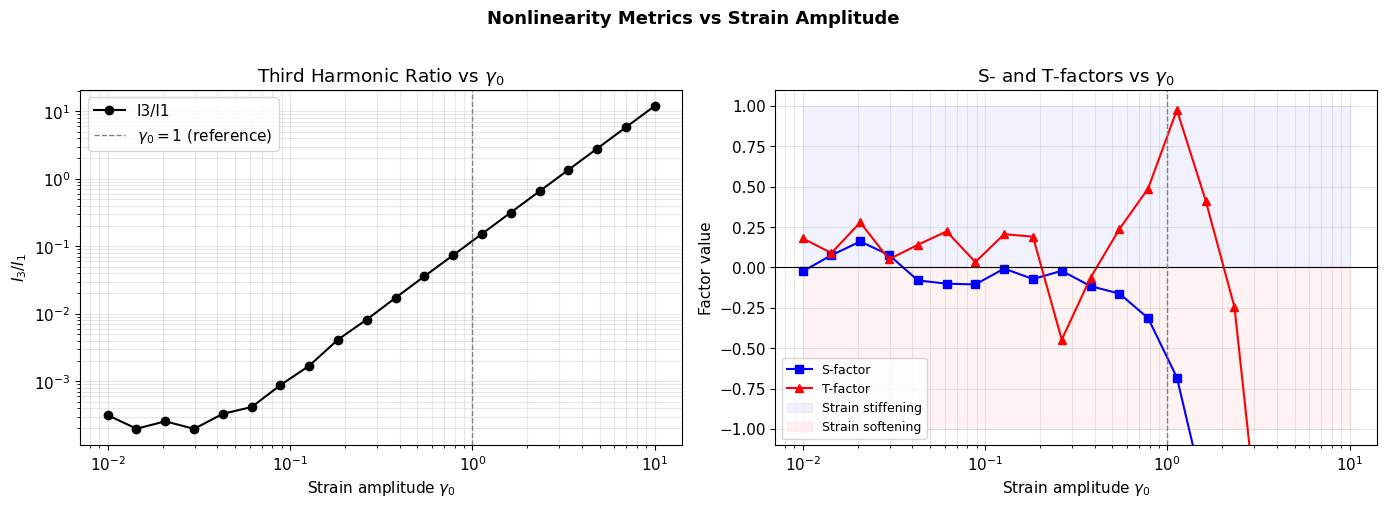

In [8]:
gamma_0_sweep = np.logspace(-2, 1, 20)  # 0.01 to 10

sweep_I3I1 = []
sweep_S = []
sweep_T = []
sweep_sigma_sy = []
sweep_sigma_dy = []

for g0 in gamma_0_sweep:
    # Scale harmonics with amplitude: 3rd harmonic grows ~g0^3 in weakly nonlinear theory
    s1 = 100.0
    # Weak 3rd harmonic that grows with g0
    s3_coeff = 12.0 / (1.0 ** 2)   # normalized to g0=1 reference
    s5_coeff = 2.0 / (1.0 ** 4)

    s3 = s3_coeff * g0**2
    s5 = s5_coeff * g0**4

    _strain = g0 * np.sin(omega * t)
    _stress = (
        s1 * np.sin(omega * t + 0.3)
        + s3 * np.sin(3 * omega * t + 0.8)
        + s5 * np.sin(5 * omega * t + 1.2)
    )
    _stress += 0.5 * np.random.randn(len(t))

    try:
        _r = spp_analyze(
            stress=_stress,
            time=t,
            omega=omega,
            gamma_0=g0,
            strain=_strain,
            n_harmonics=5,
        )
        sweep_I3I1.append(_r["I3_I1_ratio"])
        sweep_S.append(_r["S_factor"])
        sweep_T.append(_r["T_factor"])
        sweep_sigma_sy.append(_r["sigma_sy"])
        sweep_sigma_dy.append(_r["sigma_dy"])
    except Exception as exc:
        # Skip any degenerate amplitudes
        sweep_I3I1.append(np.nan)
        sweep_S.append(np.nan)
        sweep_T.append(np.nan)
        sweep_sigma_sy.append(np.nan)
        sweep_sigma_dy.append(np.nan)

sweep_I3I1 = np.array(sweep_I3I1)
sweep_S = np.array(sweep_S)
sweep_T = np.array(sweep_T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: I3/I1 vs gamma_0
ax = axes[0]
ax.loglog(gamma_0_sweep, sweep_I3I1, "ko-", linewidth=1.5, markersize=6, label="I3/I1")
ax.axvline(1.0, color="gray", linestyle="--", linewidth=1, label=r"$\gamma_0 = 1$ (reference)")
ax.set_xlabel(r"Strain amplitude $\gamma_0$")
ax.set_ylabel(r"$I_3/I_1$")
ax.set_title(r"Third Harmonic Ratio vs $\gamma_0$")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# Right: S-factor and T-factor vs gamma_0
ax = axes[1]
ax.semilogx(gamma_0_sweep, sweep_S, "bs-", linewidth=1.5, markersize=6, label="S-factor")
ax.semilogx(gamma_0_sweep, sweep_T, "r^-", linewidth=1.5, markersize=6, label="T-factor")
ax.axhline(0, color="k", linewidth=0.8)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax.fill_between(
    gamma_0_sweep, 0, 1, color="blue", alpha=0.05, label="Strain stiffening"
)
ax.fill_between(
    gamma_0_sweep, -1, 0, color="red", alpha=0.05, label="Strain softening"
)
ax.set_xlabel(r"Strain amplitude $\gamma_0$")
ax.set_ylabel("Factor value")
ax.set_title(r"S- and T-factors vs $\gamma_0$")
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

plt.suptitle(r"Nonlinearity Metrics vs Strain Amplitude", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

- **SPP decomposition** decomposes LAOS stress into physically meaningful elastic and viscous
  contributions, enabling cycle-by-cycle characterization of nonlinear viscoelasticity

- **Lissajous-Bowditch plots** are the primary visualization — the shape encodes the material
  nonlinearity: elliptical = linear, distorted = nonlinear

- **$I_3/I_1$** (third-harmonic ratio) is a scalar measure of nonlinearity from FT-rheology;
  it grows approximately as $\gamma_0^2$ in the weakly nonlinear regime

- **S-factor**:
  - $S > 0$: strain stiffening (G_L > G_M) — network stretches and hardens
  - $S < 0$: strain softening (G_L < G_M) — network breaks down under large deformation

- **T-factor**:
  - $T > 0$: shear thickening (eta_L > eta_M)
  - $T < 0$: shear thinning (eta_L < eta_M)

- **`spp_analyze()`** provides quick single-shot analysis from raw NumPy arrays with no
  boilerplate — ideal for scripted pipelines and exploratory analysis

### Further Reading

- Rogers, S.A. et al., *J. Rheol.* **56**(1), 1–25 (2012)
- Rogers, S.A., *Rheol. Acta* **56**, 811–824 (2017)
- Hyun, K. et al., *Prog. Polym. Sci.* **36**, 1697–1753 (2011) (LAOS review)

## Session Information

In [9]:
import importlib.metadata
import platform

print(f"Platform : {platform.platform()}")
print(f"Python   : {sys.version.split()[0]}")

for pkg in ["jax", "numpy", "matplotlib", "rheojax"]:
    try:
        version = importlib.metadata.version(pkg)
        print(f"{pkg:<12}: {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{pkg:<12}: not found")

print(f"\nJAX backend  : {jax.default_backend()}")
print(f"JAX devices  : {jax.devices()}")

Platform : macOS-26.5-arm64-arm-64bit-Mach-O
Python   : 3.13.9
jax         : 0.10.0
numpy       : 2.4.5
matplotlib  : 3.10.9
rheojax     : 0.6.1

JAX backend  : cpu
JAX devices  : [CpuDevice(id=0)]
